# SUPERSTORE SALES ANALYSIS

In [3]:
# Importing required Libraries for Data Analysis and visualisation
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [4]:
# Loading the Dataset from the local system
df= pd.read_csv("D:\superstore_sales.csv")

# Initial Data Exploration

In [10]:
# Display first 5 Rows of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Display Column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [5]:
# Checks shape of the dataset (Rows and Columns)
df.shape

(9800, 18)

# Dataset Information

In [6]:
# Get complete information about the dataset (data types, null values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

# Missing values and duplicates Check

In [8]:
# Checking missing values in each Column
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
# Checking duplicate Rows
df.duplicated().sum()

np.int64(0)

# Observations
 Dataset contains 9800 rows and 18 columns. 
 11 missing values found in 'Postal Code' Column. 
 No duplicate rows found in the dataset. 
 Some columns like Order Date and Ship Date are in object format (need conversion). 
 Dataset is mostly clean and requires minor preprocessing. 

# Handling Missing Values

In [5]:
df.dropna(inplace=True)

# Data Types Correction

In [8]:
df['Order Date']= pd.to_datetime(df['Order Date'], errors= 'coerce')
df['Ship Date']= pd.to_datetime(df['Ship Date'], errors= 'coerce')
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

# Statistical Summary of Numerical columns

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9789.000000,3955,3811,9789.000000,9789.000000
mean,4896.705588,2017-03-14 18:03:54.841972224,2017-04-09 14:33:58.520073472,55273.322403,230.116193
min,1.000000,2015-01-02 00:00:00,2015-01-04 00:00:00,1040.000000,0.444000
25%,2449.000000,2016-04-05 00:00:00,2016-04-12 00:00:00,23223.000000,17.248000
50%,4896.000000,2017-05-02 00:00:00,2017-06-06 00:00:00,58103.000000,54.384000
75%,7344.000000,2018-03-07 00:00:00,2018-05-01 00:00:00,90008.000000,210.392000
max,9800.000000,2018-12-11 00:00:00,2019-05-01 00:00:00,99301.000000,22638.480000
std,2827.486899,NaN,NaN,32041.223413,625.302079


# Exploratory Data Analysis

# Sales by Category

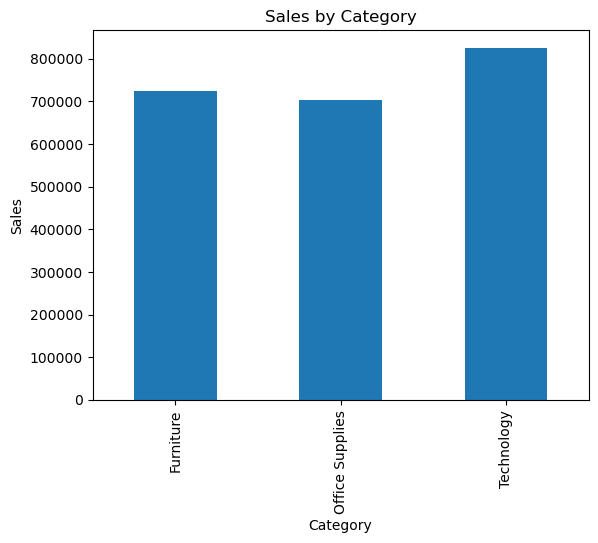

In [10]:
category_sales= df.groupby('Category')['Sales'].sum()
category_sales.plot(kind= 'bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

# Sales by Region

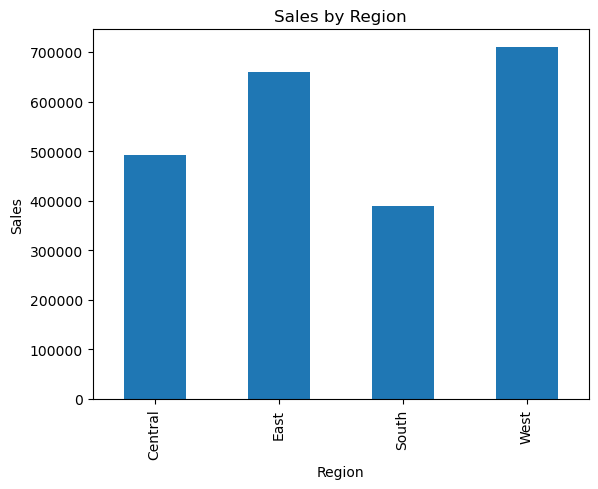

In [11]:
region_sales= df.groupby('Region')['Sales'].sum()
region_sales.plot(kind= 'bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

# Sales over Time

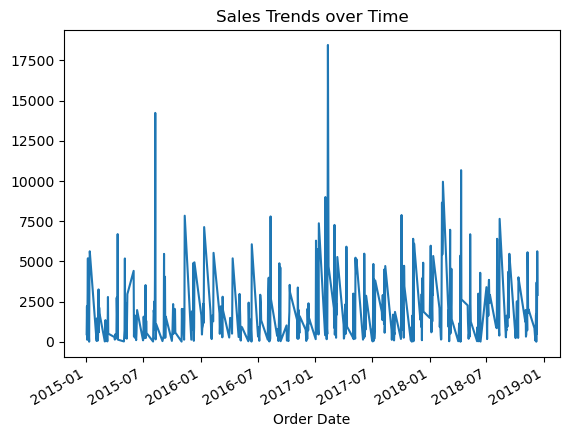

In [13]:
df.groupby('Order Date')['Sales'].sum().plot()
plt.title('Sales Trends over Time')
plt.show()

# Top 10 Products

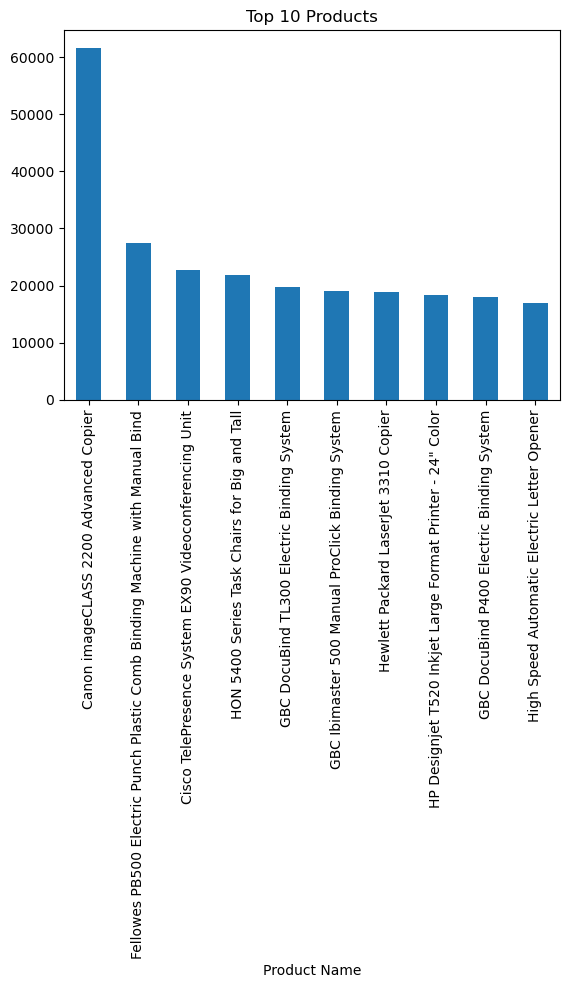

In [16]:
top_products= df.groupby('Product Name')['Sales'].sum().sort_values(ascending= False).head(10)
top_products.plot(kind= 'bar')
plt.title('Top 10 Products')
plt.show()

# Sales by Segment

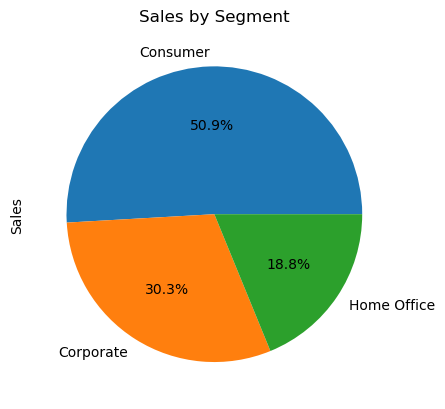

In [18]:
segment_sales= df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='pie', autopct= '%1.1f%%')
plt.title ('Sales by Segment')
plt.show()